# Agent Security Risk Analysis

This notebook trains XGBoost and Logistic Regression models to answer the two research questions:
1. Can we predict the security risk score of an AI agent's action based on its autonomy level, permissions, requested tools, and resource access patterns? 
2. Can we determine if an agent should be granted access to its request based on its security risk score?

In [41]:
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    classification_report,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import shap

plt.style.use("ggplot")

RANDOM_STATE = 42

In [42]:
load_dotenv()

# Download (or use the cached copy of) the dataset from KaggleHub
path = kagglehub.dataset_download(
    "algozee/agentic-ai-security-risk-dataset"
)

print("Dataset location:", path)
print("Files:", os.listdir(path))

csv_file = os.path.join(path, "agent_security_risk_scores.csv")
df = pd.read_csv(csv_file)

print(df.shape)
df.head()

Dataset location: /Users/deekshavaidyanathan/.cache/kagglehub/datasets/algozee/agentic-ai-security-risk-dataset/versions/1
Files: ['agent_security_risk_scores.csv']
(2200, 15)


,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
0,customer_support_agent,4,admin,read_record,file_storage_api,api_key_secret,5,0,64,0,83,0,0,1,Blocked
1,customer_support_agent,2,analyst,export_report,crm_api,sales_pipeline,3,0,66,0,65,1,2,1,Blocked
2,hr_onboarding_agent,3,vendor,change_permission,external_webhook,sales_pipeline,3,0,100,0,51,1,2,1,Blocked
3,hr_onboarding_agent,2,manager,send_email,hris_api,customer_profile,3,0,64,0,64,0,0,1,Blocked
4,finance_reconciliation_agent,1,vendor,read_record,database_api,source_code_repo,4,0,41,0,63,0,1,1,Blocked


# Dataset Overview

In [43]:
print("Columns:")
print(df.columns.tolist())

print("\nDtypes / non-null counts:")
df.info()

print("\nSummary statistics:")
df.describe(include="all")

Columns:
['agent_role', 'agent_autonomy_level', 'user_role', 'requested_action', 'tool_requested', 'resource_type', 'resource_sensitivity', 'permission_match', 'action_risk_score', 'prompt_injection_detected', 'data_exfiltration_risk', 'human_approval_required', 'previous_failed_attempts', 'audit_log_available', 'access_decision']

Dtypes / non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   agent_role                 2200 non-null   object
 1   agent_autonomy_level       2200 non-null   int64 
 2   user_role                  2200 non-null   object
 3   requested_action           2200 non-null   object
 4   tool_requested             2200 non-null   object
 5   resource_type              2200 non-null   object
 6   resource_sensitivity       2200 non-null   int64 
 7   permission_match           2200 n

,agent_role,agent_autonomy_level,user_role,requested_action,tool_requested,resource_type,resource_sensitivity,permission_match,action_risk_score,prompt_injection_detected,data_exfiltration_risk,human_approval_required,previous_failed_attempts,audit_log_available,access_decision
count,2200,2200.000000,2200,2200,2200,2200,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200
unique,11,NaN,9,13,12,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,customer_support_agent,NaN,employee,read_record,database_api,customer_profile,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Blocked
freq,402,NaN,566,463,338,314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1435
mean,NaN,3.114091,NaN,NaN,NaN,NaN,3.121818,0.392273,54.819545,0.055909,55.661818,0.420909,0.983182,0.921364,NaN
std,NaN,1.088692,NaN,NaN,NaN,NaN,1.195214,0.488368,27.931910,0.229798,20.771701,0.493817,1.474411,0.269232,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,2.000000,0.000000,2.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,35.000000,0.000000,40.000000,0.000000,0.000000,1.000000,NaN
50%,NaN,3.000000,NaN,NaN,NaN,NaN,3.000000,0.000000,54.000000,0.000000,55.000000,0.000000,0.000000,1.000000,NaN
75%,NaN,4.000000,NaN,NaN,NaN,NaN,4.000000,1.000000,76.000000,0.000000,69.000000,1.000000,2.000000,1.000000,NaN


# XGBoost Risk Score Prediction

Predicts the numerical `action_risk_score` from the request's security-relevant features.

In [44]:
target = "action_risk_score"
cols_to_remove = ["human_approval_required", "access_decision", "prompt_injection_detected", "user_role"]
categorical_columns = ["agent_role", "requested_action", "tool_requested", "resource_type"]

# one-hot encode categorical variables using pd.get_dummies
X = pd.get_dummies(df.drop(columns=[target] + cols_to_remove), columns=categorical_columns)

y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
)

xgb_model.fit(X_train, y_train)

predictions = xgb_model.predict(X_test)

print("R^2:", round(r2_score(y_test, predictions), 3))
print("MAE:", round(mean_absolute_error(y_test, predictions), 2))

R^2: 0.902
MAE: 6.61


# SHAP Explainability

SHAP values show which features push a given prediction up or down, and by how much.

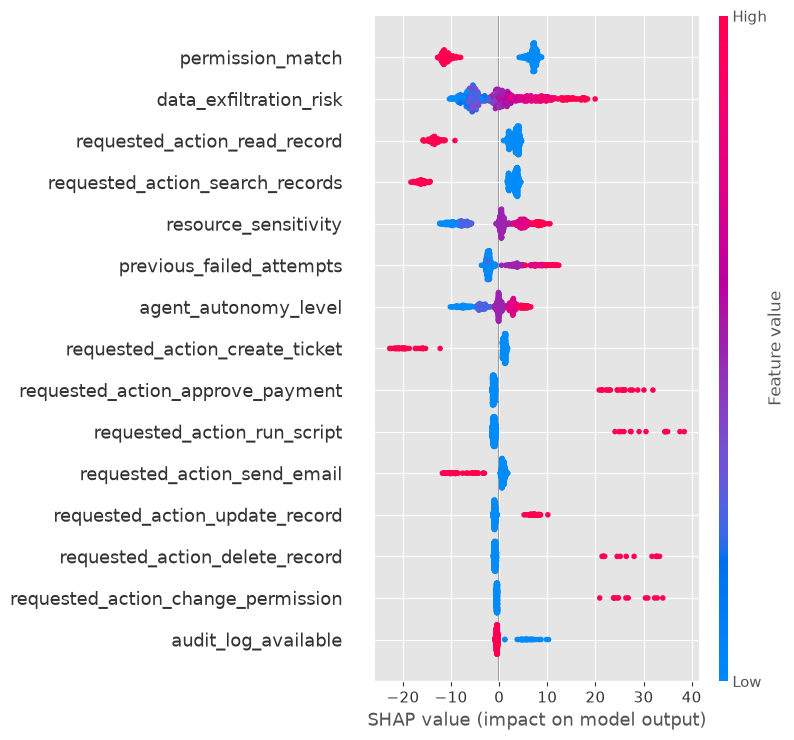

In [45]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)

In [46]:
# Rank features by average absolute SHAP value (impact on score)
importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns,
)

print("Top 15 drivers of the risk score:")
print(importance.sort_values(ascending=False).head(15))

Top 15 drivers of the risk score:
permission_match                      8.670886
data_exfiltration_risk                5.153768
requested_action_read_record          5.149649
requested_action_search_records       5.098706
resource_sensitivity                  4.777599
previous_failed_attempts              3.059783
agent_autonomy_level                  2.683564
requested_action_create_ticket        2.458328
requested_action_approve_payment      2.086430
requested_action_run_script           1.818642
requested_action_send_email           1.674982
requested_action_update_record        1.572976
requested_action_delete_record        1.470074
requested_action_change_permission    1.173301
audit_log_available                   0.852239
dtype: float32


# Logistic Regression: Predicting the Access Decision

Predicts whether a request should be Allowed or Blocked based solely on the action_risk_score.

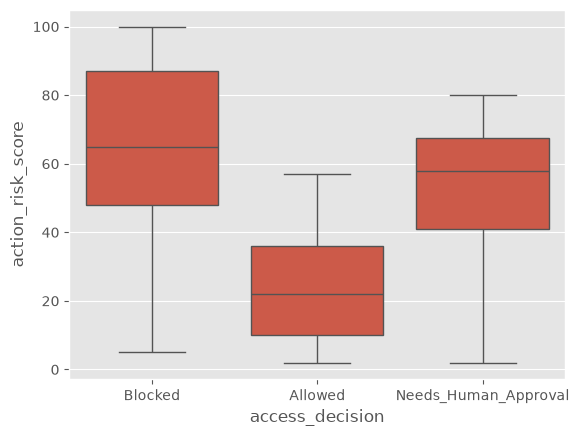

In [47]:
# demonstrates that the three access_decision categories overlap quite significantly in terms of their risk scores
# therefore, it is difficult for an ML model to predict access_decision solely based on action_risk_score

sns.boxplot(data=df, x="access_decision", y="action_risk_score")
plt.show()

In [48]:
# removing the Needs_Human_Approval column to improve performance
df_binary = df[df["access_decision"] != "Needs_Human_Approval"].copy()

X_decision = df_binary[["action_risk_score"]]

y_decision = df_binary["access_decision"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_decision_scaled,
    y_decision,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_decision,
)

scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_d)
X_test_d = scaler.transform(X_test_d)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_d, y_train_d)

pred_decision = log_model.predict(X_test_d)

print(classification_report(y_test_d, pred_decision))

              precision    recall  f1-score   support

     Allowed       0.78      0.64      0.70       132
     Blocked       0.87      0.93      0.90       359

    accuracy                           0.85       491
   macro avg       0.83      0.78      0.80       491
weighted avg       0.85      0.85      0.85       491



## Answering Research Question #2
1. Any machine learning model will struggle to predict access_decision from just action_risk_score because the data across the access_decision categories overlaps quite significantly, as shown by the graph (particularly "Needs Human Approval"). For instance, there are rows  with action_risk_scores of 59 that have Blocked, Accepted, and Needs Human Approval access_decisions, so a model will not be able to predict it cleanly without additional information.

2. Removing the Needs Human Approval category significantly improves the performance of the logistic regression model, which is now able to predict at an 85% accuracy rate compared to 59% when it had the Needs Human Approval category. This is a valid narrowing of the research question, as we are now asking specifically "does action_risk_score predict Allowed vs. Blocked?" rather than the 3-way decision. However, this exclusion should be justified simply as removing an ambiguous middle category to isolate a cleaner binary question, not as something already captured elsewhere: our crosstab analysis revealed human_approval_required does not reliably track the Needs_Human_Approval label (missing ~41% of those rows) or align cleanly with Blocked/Allowed either, so the two columns appear to reflect different, and only partially related, aspects of the decision process. Therefore, the decision to remove the Needs Human Approval category is solely to narrow the research question, not to be subtituted for by the human_approval_required column.

3. So the answer to our second research question, whether action_risk_score can predict access_decision is: somewhat. This testing demonstrated that the relationship between action_risk_score and access_decision is not as linear as we initially imagined, and that there are other factors that influence access_decision apart from action_risk_score. However, some data cleaning enables us to predict with 85% accuracy whether an access_decision will be blocked or allowed solely based on the action_risk_score. Ultimately, training a model on all the features is a better strategy if predicting access_decision is the goal.